# MVP — Diagnostic de robustesse des modèles d'IA face à la dégradation des données

**Consulting Project — Hiba ITSMAIL — Epitech Digital School**

**Sujet :** *Dans quelle mesure la dégradation de la qualité des données affecte-t-elle la robustesse des modèles d'IA supervisés utilisés pour la prise de décision en entreprise ?*

Ce notebook constitue le **MVP** (Produit Minimum Viable) du mémoire. Il met en œuvre un **cadre de diagnostic en 4 étapes** :

1. **Audit de qualité** — mesurer le taux de valeurs manquantes, de doublons, d'incohérences.
2. **Contrôle avant entraînement** — vérifier que la qualité dépasse un seuil minimal.
3. **Diagnostic de robustesse** — dégrader les données et tracer les courbes de chute.
4. **Monitoring** — alerter si la performance passe sous un seuil critique.

**Cas d'étude :** prévision du chiffre d'affaires (CA) d'articles, à partir de données de ventes
synthétiques reproduisant la structure de la Direction Marketing de Saint-Gobain Distribution Bâtiment France.

> Données **synthétiques** (confidentialité + contrôle expérimental + reproductibilité). Graine fixée = 42.


## 0. Imports et configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

SEED = 42                      # graine fixe -> reproductibilite totale
rng = np.random.default_rng(SEED)
NIVEAUX = [0.0, 0.05, 0.10, 0.20, 0.40]   # niveaux de degradation testes
pd.set_option("display.width", 120)

## 1. Génération du jeu de données synthétique

On reproduit la structure réelle (région, site, agence, hiérarchie produit, quantité) avec des
**relations métier** : le CA dépend de la quantité, du prix moyen par famille et d'un effet régional.

In [ ]:
def generer_donnees(n=4000, seed=SEED):
    rng = np.random.default_rng(seed)
    familles = {
        "Couverture": ["Tuiles", "Ardoises", "Zinguerie"],
        "Isolation":  ["Laine de verre", "Laine de roche", "Polystyrene"],
        "Platre":     ["Plaques", "Carreaux", "Enduits"],
        "Menuiserie": ["Fenetres", "Portes", "Volets"],
        "Outillage":  ["Manuel", "Electroportatif", "Consommables"],
    }
    regions = ["Nord", "Sud", "Est", "Ouest", "Ile-de-France"]
    prix    = {"Couverture":18,"Isolation":12,"Platre":9,"Menuiserie":140,"Outillage":35}
    base_q  = {"Couverture":120,"Isolation":200,"Platre":300,"Menuiserie":60,"Outillage":150}
    eff_reg = {"Nord":1.0,"Sud":1.05,"Est":0.95,"Ouest":1.0,"Ile-de-France":1.2}

    rows = []
    for _ in range(n):
        fam = rng.choice(list(familles))
        sfam = rng.choice(familles[fam])
        region = rng.choice(regions)
        site = f"Site {region} {rng.integers(1,4)}"
        agence = f"{site} - Ag.{rng.integers(1,5)}"
        code_art = f"ART{rng.integers(10000,99999)}"
        libelle = f"{sfam} {rng.choice(['Std','Pro','Eco','Premium'])}"
        quantite = max(1, int(rng.normal(base_q[fam], base_q[fam]*0.35)))
        pu = prix[fam] * rng.normal(1.0, 0.15)
        ca = quantite * pu * eff_reg[region] * rng.normal(1.0, 0.08)   # CIBLE
        rows.append([code_art, libelle, region, site, agence, fam, sfam,
                     round(ca,2), float(quantite)])
    cols = ["code_article","libelle","region","site","agence","famille",
            "sous_famille","CA","quantite"]
    return pd.DataFrame(rows, columns=cols)

df = generer_donnees()
print("Dimensions :", df.shape)
df.head()

Dimensions : (4000, 9)


,code_article,libelle,region,site,agence,famille,sous_famille,CA,quantite
0,ART87272,Zinguerie Std,Ouest,Site Ouest 2,Site Ouest 2 - Ag.2,Couverture,Zinguerie,556.03,38.0
1,ART85576,Volets Pro,Ouest,Site Ouest 2,Site Ouest 2 - Ag.1,Menuiserie,Volets,12258.44,78.0
2,ART30451,Enduits Std,Est,Site Est 2,Site Est 2 - Ag.2,Platre,Enduits,1917.95,199.0
3,ART16112,Plaques Premium,Ouest,Site Ouest 3,Site Ouest 3 - Ag.2,Platre,Plaques,2316.22,283.0
4,ART23885,Laine de roche Eco,Est,Site Est 1,Site Est 1 - Ag.3,Isolation,Laine de roche,3582.95,349.0


## 2. Définition des variables et des modèles

- **Cible :** `CA` (régression).
- **Variables explicatives :** quantité (numérique) + région / famille / sous-famille (catégorielles).
- On retire les identifiants (`code_article`, `libelle`) et on n'utilise pas d'historique dominant,
  pour que la dégradation ait un effet visible.
- **4 modèles** aux logiques différentes, pour comparer leur robustesse.

In [ ]:
TARGET = "CA"
NUM_COLS = ["quantite"]
CAT_COLS = ["region", "famille", "sous_famille"]   # cardinalite raisonnable (calcul rapide)

def make_pipe(model):
    """Pipeline : imputation -> encodage/normalisation -> modele."""
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), NUM_COLS),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), CAT_COLS),
    ])
    return Pipeline([("prep", pre), ("model", model)])

def modeles():
    return {
        "Regression lineaire": LinearRegression(),
        "Random Forest":       RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
        "XGBoost":             XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.1,
                                            random_state=SEED, verbosity=0),
        "SVR":                 SVR(C=100, gamma="scale"),
    }

CV = KFold(n_splits=5, shuffle=True, random_state=SEED)

## 3. Étape 1 du cadre — Audit de qualité

Première brique du MVP : une fonction qui **mesure la qualité d'un jeu de données**
(taux de valeurs manquantes, doublons) et renvoie un score global.

In [ ]:
def audit_qualite(data):
    n = len(data)
    taux_manquants = data.isna().mean().mean()          # part moyenne de cellules vides
    taux_doublons  = data.duplicated().mean()           # part de lignes dupliquees
    score = (1 - taux_manquants) * (1 - taux_doublons)  # score simple in [0,1]
    return {
        "lignes": n,
        "taux_manquants_%": round(taux_manquants*100, 2),
        "taux_doublons_%":  round(taux_doublons*100, 2),
        "score_qualite":    round(score, 3),
    }

audit_qualite(df)

{'lignes': 4000,
 'taux_manquants_%': np.float64(0.0),
 'taux_doublons_%': np.float64(0.0),
 'score_qualite': np.float64(1.0)}

## 4. Étape 2 du cadre — Contrôle avant entraînement

On définit un **seuil minimal de qualité**. Si le score est en dessous, le MVP déconseille
l'entraînement (principe du *garbage in, garbage out*).

In [ ]:
SEUIL_QUALITE = 0.90

def controle_avant_entrainement(data, seuil=SEUIL_QUALITE):
    a = audit_qualite(data)
    ok = a["score_qualite"] >= seuil
    print(f"Score qualite = {a['score_qualite']}  (seuil = {seuil})")
    print("OK pour entrainement." if ok else "ALERTE : qualite insuffisante, entrainement deconseille.")
    return ok

controle_avant_entrainement(df)

Score qualite = 1.0  (seuil = 0.9)
OK pour entrainement.


np.True_

<Axes: ylabel='famille'>

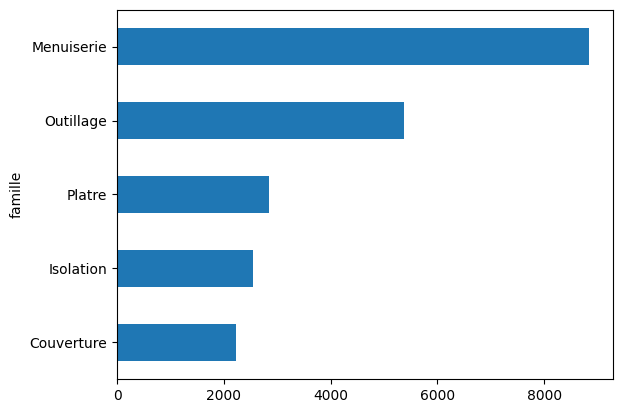

In [ ]:
df.groupby('famille')['CA'].mean().sort_values().plot(kind='barh')



## 5. Baseline — performance sur données propres

Le **point 0** : on entraîne les 4 modèles sur les données propres (validation croisée 5-fold).
Tout le reste se mesure par rapport à cette référence.

In [ ]:
def evaluer(data, target=TARGET):
    X = data[NUM_COLS + CAT_COLS]
    y = data[target].values.astype(float)
    scores = {}
    for nom, mdl in modeles().items():
        r2 = cross_val_score(make_pipe(mdl), X, y, cv=CV, scoring="r2").mean()
        scores[nom] = round(r2, 3)
    return scores

baseline = evaluer(df)
print("R2 baseline (donnees propres) :")
for k, v in baseline.items():
    print(f"  {k:<22}: {v}")



R2 baseline (donnees propres) :
  Regression lineaire   : 0.731
  Random Forest         : 0.888
  XGBoost               : 0.895
  SVR                   : 0.721


## 6. Fonctions de dégradation contrôlée

Cinq types de dégradation, applicables à un niveau réglable (proportion de lignes affectées).

In [ ]:
def deg_valeurs_manquantes(X, y, r):
    Xd = X.copy()
    for col in Xd.columns:
        Xd.loc[rng.random(len(Xd)) < r, col] = np.nan
    return Xd, y

def deg_bruit_variables(X, y, r):
    Xd = X.copy()
    m = rng.random(len(Xd)) < r
    Xd.loc[m, "quantite"] = Xd.loc[m, "quantite"].astype(float) * rng.normal(1.0, 0.5, m.sum())
    mc = rng.random(len(Xd)) < r
    Xd.loc[mc, "famille"] = rng.choice(Xd["famille"].unique(), mc.sum())
    return Xd, y

def deg_bruit_cible(X, y, r):
    yd = y.copy()
    m = rng.random(len(yd)) < r
    yd[m] = yd[m] * rng.normal(1.0, 0.5, m.sum())   # equivalent du "mauvais etiquetage" en regression
    return X.copy(), yd

def deg_incoherences(X, y, r):
    Xd = X.copy()
    m = rng.random(len(Xd)) < r
    Xd.loc[m, "quantite"] = Xd.loc[m, "quantite"].astype(float) * 1000   # melange d'unites
    return Xd, y

def deg_derive(X, y, r):
    Xd, yd = X.copy(), y.copy()
    m = rng.random(len(Xd)) < r
    Xd.loc[m, "quantite"] = Xd.loc[m, "quantite"].astype(float) * rng.uniform(1.5, 2.5)  # distribution change
    yd[m] = yd[m] * 0.6                                                                   # relation change
    return Xd, yd

DEGRADATIONS = {
    "Valeurs manquantes": deg_valeurs_manquantes,
    "Bruit (variables)":  deg_bruit_variables,
    "Bruit (cible)":      deg_bruit_cible,
    "Incoherences":       deg_incoherences,
    "Derive (drift)":     deg_derive,
}

## 7. Étape 3 du cadre — Diagnostic de robustesse

On applique chaque dégradation à chaque niveau, on ré-entraîne, et on stocke le R².
*(Le calcul peut prendre quelques minutes ; réduire `n` ou le nombre de folds pour accélérer.)*

In [ ]:
X0 = df[NUM_COLS + CAT_COLS].copy()
X0["quantite"] = X0["quantite"].astype(float)
y0 = df[TARGET].values.astype(float)

resultats = {}   # resultats[degradation][modele] = [R2 par niveau]
for dnom, dfun in DEGRADATIONS.items():
    resultats[dnom] = {m: [] for m in modeles()}
    for lvl in NIVEAUX:
        Xd, yd = dfun(X0, y0, lvl)
        for nom, mdl in modeles().items():
            r2 = cross_val_score(make_pipe(mdl), Xd, yd, cv=CV, scoring="r2").mean()
            resultats[dnom][nom].append(r2)
    print(f"OK : {dnom}")
print("Diagnostic termine.")

OK : Valeurs manquantes
OK : Bruit (variables)
OK : Bruit (cible)
OK : Incoherences
OK : Derive (drift)
Diagnostic termine.


### 7.1 Courbes de dégradation

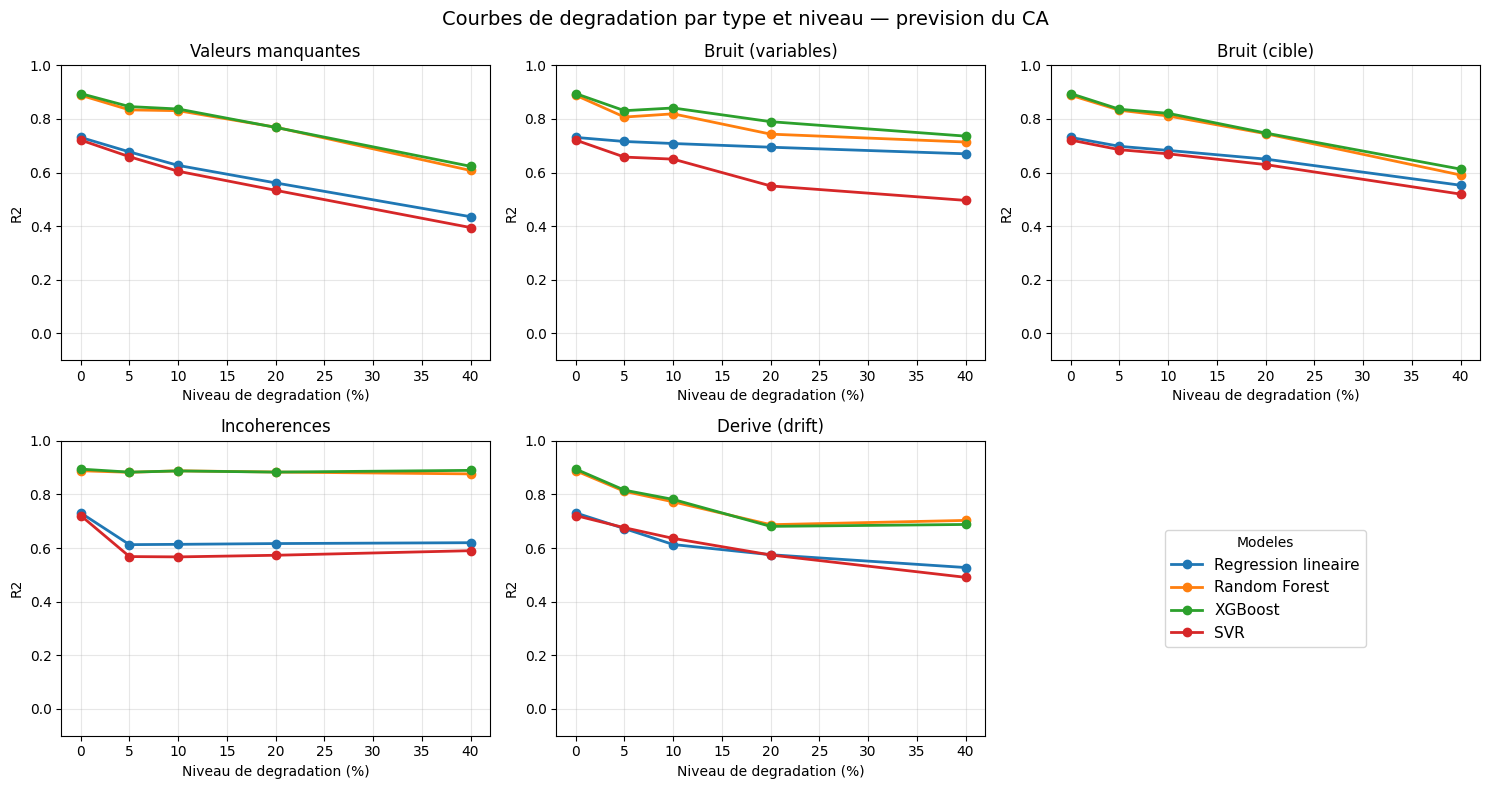

In [ ]:
xs = [int(l*100) for l in NIVEAUX]
fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.ravel()
for i, (dnom, res) in enumerate(resultats.items()):
    ax = axes[i]
    for m in res:
        ax.plot(xs, res[m], marker="o", linewidth=2, label=m)
    ax.set_title(dnom); ax.set_xlabel("Niveau de degradation (%)"); ax.set_ylabel("R2")
    ax.set_ylim(-0.1, 1.0); ax.grid(alpha=0.3)
axes[5].axis("off")
h, l = axes[0].get_legend_handles_labels()
axes[5].legend(h, l, loc="center", title="Modeles", fontsize=11)
plt.suptitle("Courbes de degradation par type et niveau — prevision du CA", fontsize=14)
plt.tight_layout(); plt.show()

### 7.2 Tableau de synthèse — perte relative de R² (0 % → 40 %)

In [ ]:
mods = list(modeles().keys())
synth = pd.DataFrame(index=list(DEGRADATIONS), columns=mods, dtype=float)
for dnom, res in resultats.items():
    for m in mods:
        r0, r40 = res[m][0], res[m][-1]
        synth.loc[dnom, m] = round((r0 - r40) / abs(r0) * 100, 1) if r0 != 0 else np.nan
synth.loc["MOYENNE"] = synth.mean().round(1)
print("Perte relative de R2 en % (plus c'est bas, plus le modele est robuste) :")
synth

Perte relative de R2 en % (plus c'est bas, plus le modele est robuste) :


,Regression lineaire,Random Forest,XGBoost,SVR
Valeurs manquantes,40.5,31.6,30.3,45.2
Bruit (variables),8.4,19.6,17.7,31.2
Bruit (cible),24.4,33.5,31.5,27.9
Incoherences,15.2,1.3,0.5,18.2
Derive (drift),27.9,20.8,23.1,31.9
MOYENNE,23.3,21.4,20.6,30.9


## 8. Étape 4 du cadre — Monitoring et alerte

Dernière brique : une fonction qui, pour un jeu de données en production, **déclenche une alerte**
si la performance estimée passe sous un seuil critique.

In [ ]:
SEUIL_ALERTE_R2 = 0.70

def monitoring(data, seuil=SEUIL_ALERTE_R2):
    scores = evaluer(data)
    meilleur = max(scores, key=scores.get)
    r2 = scores[meilleur]
    statut = "OK" if r2 >= seuil else "ALERTE — re-entrainement recommande"
    print(f"Meilleur modele : {meilleur} (R2={r2}) -> {statut}")
    return scores

# Exemple : monitoring sur donnees propres, puis sur donnees fortement degradees
print(">> Donnees propres :");        _ = monitoring(df)
Xd, yd = deg_valeurs_manquantes(X0, y0, 0.40)
deg_df = Xd.copy(); deg_df[TARGET] = yd
print("\n>> Donnees degradees a 40% :"); _ = monitoring(deg_df)

>> Donnees propres :
Meilleur modele : XGBoost (R2=0.895) -> OK

>> Donnees degradees a 40% :
Meilleur modele : XGBoost (R2=0.591) -> ALERTE — re-entrainement recommande


## 9. Conclusion du MVP

Ce prototype démontre, de bout en bout, le **cadre de diagnostic de la robustesse** proposé :
il audite la qualité d'un jeu de données, contrôle son aptitude à l'entraînement, mesure la
sensibilité comparée des modèles à cinq types de dégradation, et alerte en cas de perte de fiabilité.

**Principaux enseignements** (voir tableau de synthèse) :
- toutes les dégradations n'ont pas le même impact ;
- aucun modèle n'est le plus robuste sur tous les types de dégradation ;
- la dérive et les valeurs manquantes sont les plus pénalisantes, ce qui justifie un **monitoring continu**.

